# Optimizing Delivery ETAs with Graph-Based Network Intelligence

**Team Members:**

*  Rutuja Shyamrao Kabadi
*  Wagh Unmesh Pradeep


                  

We model the delivery network as a **directed graph** facilities are
nodes, and the lanes between them ("corridors") are edges weighted by how badly they
typically run late. From this graph we:

1. Identify structural **bottleneck hubs** using centrality measures (Phase 3)
2. Learn **Node2Vec embeddings** that encode each facility's role in the network,
   and test whether adding them to an ETA regressor improves prediction accuracy
   over the OSRM baseline (Phase 4)
3. Build a **route-type decision framework** (FTL vs. Carting) that uses both
   corridor-level delay history and graph-position features (Phase 5)

## Notebook Structure

Phase 1: Data loading, cleaning, and exploratory analysis

Phase 2: Feature engineering and graph construction

Phase 3: Bottleneck and corridor analysis

Phase 4: Node2Vec embeddings with ETA prediction

Phase 5: FTL vs Carting route classification



## Phase 1: Setup & Data Loading

Standard imports plus `networkx` for the graph work that comes later. we're
suppressing `FutureWarning`s globally because newer pandas versions throw a lot
of groupby/observed-related deprecation noise that clutters the output without
affecting correctness here.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42  # fixed seed used everywhere for reproducibility

In [3]:
df = pd.read_csv("delivery_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


### Quick structural check

Before doing anything else: how big is this dataset, what are the dtypes, and
is there missing data that we need to handle?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [6]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]

source_name         0.202254
destination_name    0.180165
dtype: float64

In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


**Observations:**
- There are no duplicate rows.
- A small number of columns (`source_name`, `destination_name`, `od_start_time`,
  `od_end_time`) have minor missingness, these aren't used in the modelling
  pipeline below, so we leave them as-is rather than imputing.
- The four timestamp columns are loaded as strings and need conversion to
  `datetime` before we can extract hour-of-day / day-of-week features.

In [9]:
time_cols = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df[time_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   trip_creation_time  144867 non-null  datetime64[ns]
 1   od_start_time       144867 non-null  datetime64[ns]
 2   od_end_time         144867 non-null  datetime64[ns]
 3   cutoff_timestamp    141438 non-null  datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 4.4 MB


## Phase 1b: Exploratory Data Analysis

The goal of this EDA is narrow and deliberate: we're not exploring for exploration's
sake we're checking the things that determine how we build the graph and define
the target variable in Phase 2. Specifically:

1. What does the core ETA-gap variable (`segment_factor` = actual time / OSRM time)
   look like, and does it need cleaning?
2. Do `route_type` and time-of-day actually correlate with delay (justifying their
   use as edge attributes / stratification keys)?
3. Are there obvious outliers or invalid records to filter before graph
   construction?

In [11]:
df['route_type'].value_counts()

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64

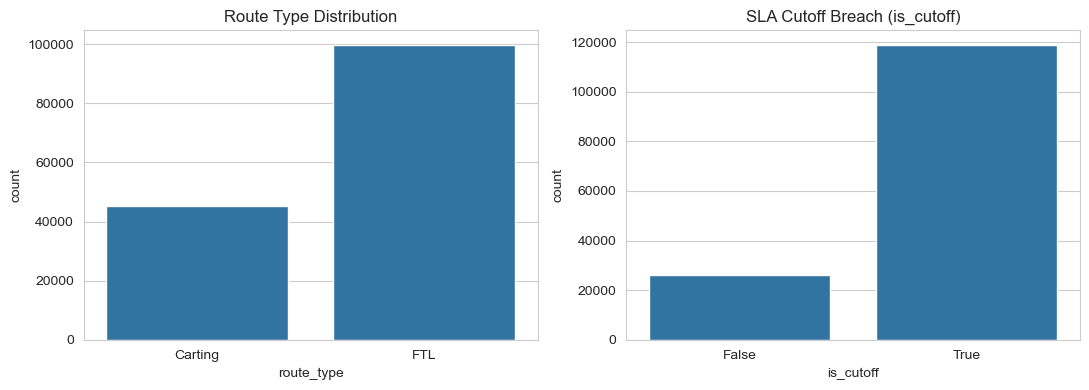

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x='route_type', ax=axes[0])
axes[0].set_title('Route Type Distribution')

sns.countplot(data=df, x='is_cutoff', ax=axes[1])
axes[1].set_title('SLA Cutoff Breach (is_cutoff)')

plt.tight_layout()
plt.show()

Carting dominates by volume (it's the default mode for shorter, last-mile
hops), while FTL (Full Truck Load) is used for longer trunk routes. This matters
later: when we build the FTL vs. Carting classifier in Phase 5, the class
imbalance shown here is exactly why we use `class_weight='balanced'`.

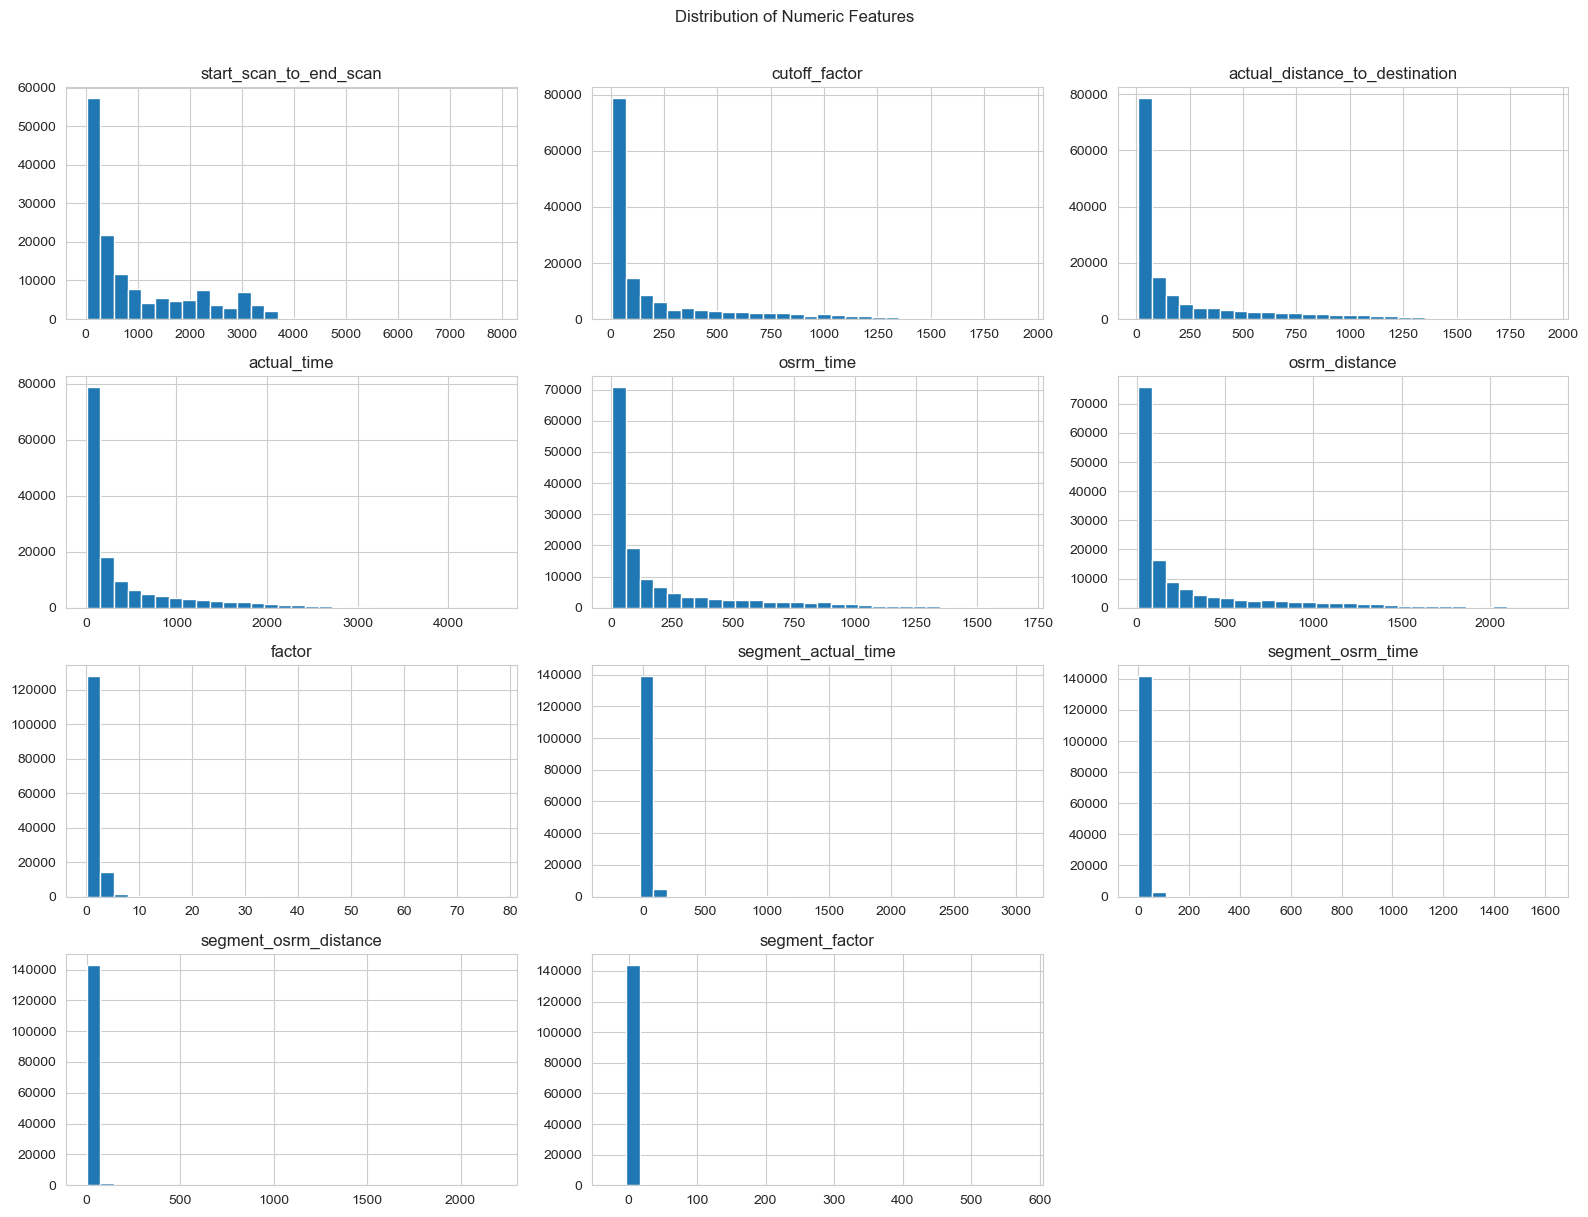

In [14]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle('Distribution of Numeric Features', y=1.01)
plt.tight_layout()
plt.show()

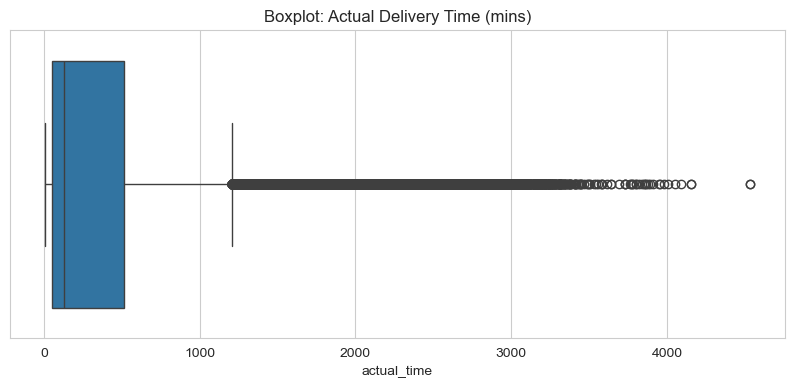

In [15]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='actual_time')
plt.title('Boxplot: Actual Delivery Time (mins)')
plt.show()

`actual_time` has a long right tail of extreme outliers (multi-day trips,
likely multi-leg shipments rather than single segments). We don't drop these from
the raw dataframe they're legitimate trips but we do need to be careful that
the **segment-level** columns (`segment_actual_time`, `segment_osrm_time`,
`segment_factor`) we actually model on don't carry the same pathological tail.
That's handled in the cleaning step below.

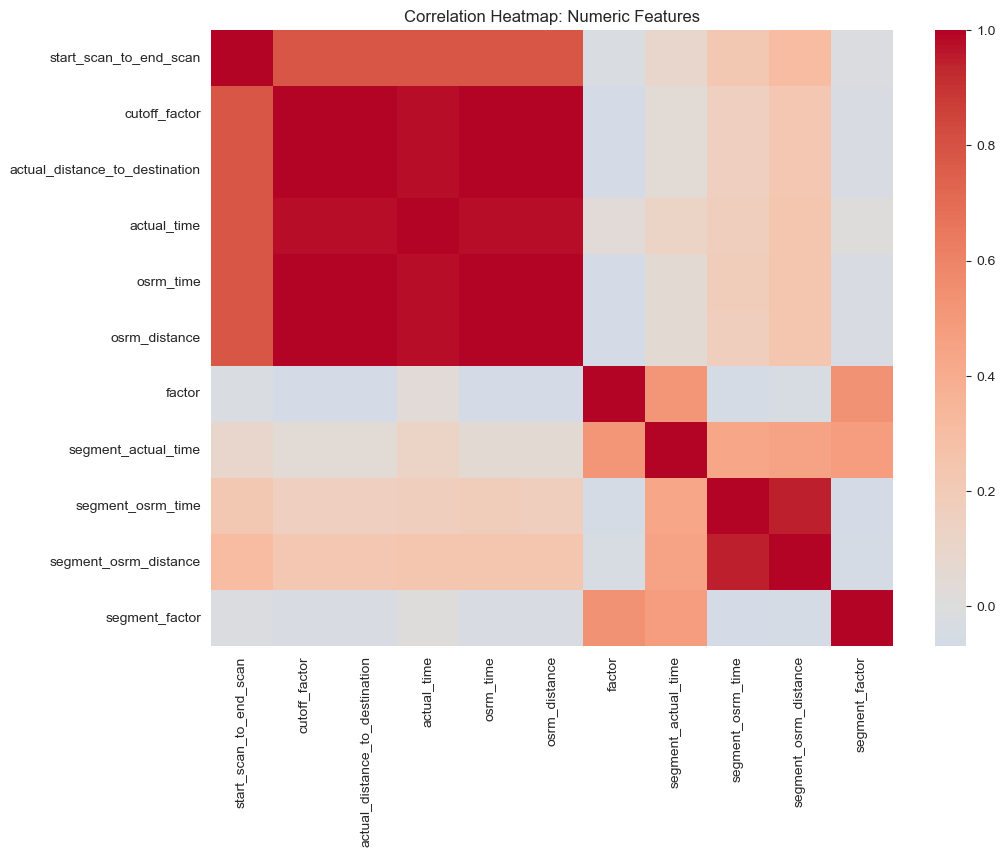

In [17]:
plt.figure(figsize=(11, 8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Numeric Features')
plt.show()

### Time-based features

`trip_creation_time` is the only fully-populated timestamp, so we derive all
calendar features from it. `trip_hour` in particular will drive the
time-of-day binning used later for graph edge stratification.

In [19]:
df['trip_year']    = df['trip_creation_time'].dt.year
df['trip_month']   = df['trip_creation_time'].dt.month
df['trip_day']     = df['trip_creation_time'].dt.day
df['trip_weekday'] = df['trip_creation_time'].dt.day_name()
df['trip_hour']    = df['trip_creation_time'].dt.hour

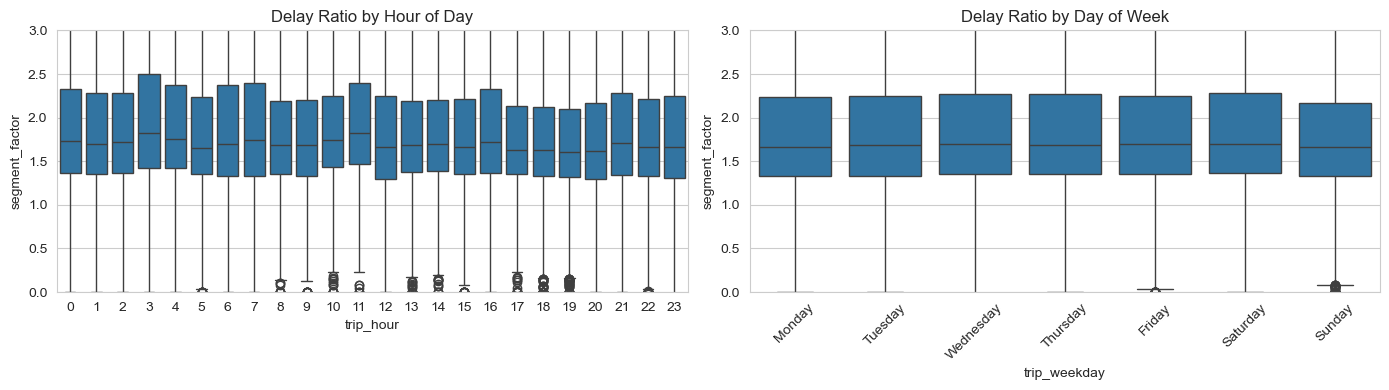

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=df, x='trip_hour', y='segment_factor', ax=axes[0])
axes[0].set_title('Delay Ratio by Hour of Day')
axes[0].set_ylim(0, 3)

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(data=df, x='trip_weekday', y='segment_factor', ax=axes[1], order=order)
axes[1].set_title('Delay Ratio by Day of Week')
axes[1].set_ylim(0, 3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

There's a visible time-of-day pattern in `segment_factor` (the actual/OSRM
ratio) this is the empirical justification for stratifying graph edges by
**time-of-day** later, rather than collapsing everything into one static weight
per corridor. Day-of-week shows much weaker separation, so we don't stratify by it
(it's still passed to the ML models as a numeric feature, but not used as a graph
dimension).

### Defining "delayed"

we define a trip as delayed if `segment_factor > 1.2`, i.e. the actual segment
time is more than 20% above OSRM's prediction. 20% is a reasonable operational
SLA buffer, it's wide enough to absorb normal traffic noise but tight enough to
flag systematic underestimation.

In [22]:
df['is_delayed'] = (df['segment_factor'] > 1.2).astype(int)
print(f"% of segments delayed (>20% over OSRM): {df['is_delayed'].mean()*100:.1f}%")

% of segments delayed (>20% over OSRM): 83.0%


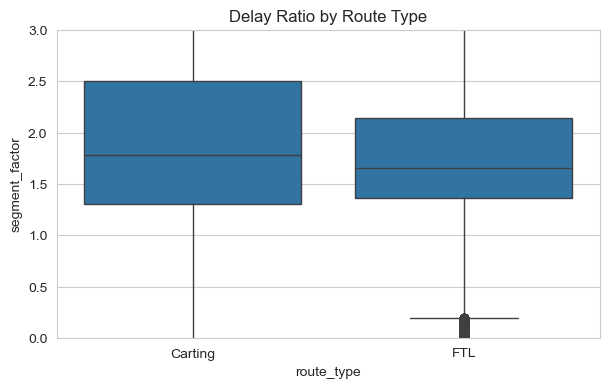

In [23]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='route_type', y='segment_factor')
plt.ylim(0, 3)
plt.title('Delay Ratio by Route Type')
plt.show()

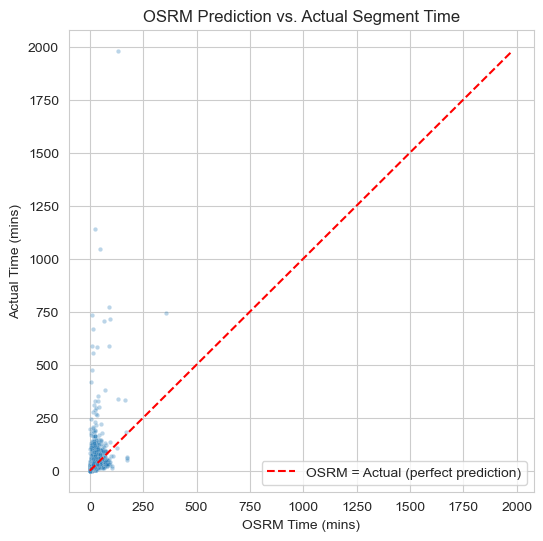

In [24]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=df.sample(5000, random_state=RANDOM_STATE),
    x='segment_osrm_time', y='segment_actual_time',
    alpha=0.3, s=10
)
max_v = df[['segment_osrm_time','segment_actual_time']].sample(5000, random_state=RANDOM_STATE).max().max()
plt.plot([0, max_v], [0, max_v], 'r--', label='OSRM = Actual (perfect prediction)')
plt.xlabel('OSRM Time (mins)')
plt.ylabel('Actual Time (mins)')
plt.title('OSRM Prediction vs. Actual Segment Time')
plt.legend()
plt.show()

Most points sit **above** the red line OSRM systematically underestimates
actual time. This is the entire premise of the project: there's a gap, and the
question is whether network structure can help close it.

### Worst corridors at a glance

Before formal graph construction, a quick groupby gives an early signal of which
source destination pairs run worst useful as a sanity check against the
graph-based "chronic delay corridor" analysis in Phase 3.

In [26]:
df['corridor'] = df['source_center'] + ' -> ' + df['destination_center']

df.groupby('corridor')['segment_factor'].median().sort_values(ascending=False).head(10)

corridor
IND571105AAA -> IND571114AAA    81.700000
IND208012AAA -> IND209304AAA    35.000000
IND785634AAA -> IND785001AAA    31.200000
IND842003AAB -> IND482002AAA    23.187500
IND424304AAC -> IND424006AAA    22.313663
IND425405AAA -> IND424006AAA    21.185587
IND722140AAA -> IND723130AAA    19.130435
IND121002AAA -> IND121004AAB    19.083333
IND221313AAA -> IND221401AAA    16.714286
IND151103AAA -> IND151001AAA    15.672365
Name: segment_factor, dtype: float64

## Phase 1c: Cleaning the Modelling Columns

Three cleaning decisions, each justified:

1. **Rename `segment_factor` - `delay_ratio`** purely for readability; this is
   the column we'll refer to constantly from here on.
2. **Drop rows with non-positive `segment_osrm_time` / `segment_actual_time`**
   a time of 0 or less is a data error (you can't traverse a segment instantly
   or in negative time), and it would make `delay_ratio` undefined or nonsensical.
3. **Cap `delay_ratio` at the 99th percentile** - a small number of segments have
   delay ratios in the hundreds or thousands (almost certainly logging errors,
   e.g. a segment marked as taking 1 minute by OSRM but several hours in
   practice). Without capping, these extreme values would dominate both the
   graph edge weights (Phase 2) and the regression target distribution
   (Phase 4), distorting both for the 99% of normal trips. Winsorizing at p99
   keeps the signal from genuinely bad corridors while removing the influence of
   what are likely data artifacts.

In [28]:
df = df.rename(columns={'segment_factor': 'delay_ratio'})

initial_rows = len(df)
df = df[
    (df['segment_osrm_time'] > 0) &
    (df['segment_actual_time'] > 0)
].copy()
print(f"Dropped {initial_rows - len(df):,} rows with invalid (<=0) segment times "
      f"({(initial_rows - len(df)) / initial_rows * 100:.2f}% of data).")

p99 = df['delay_ratio'].quantile(0.99)
df['delay_ratio'] = df['delay_ratio'].clip(upper=p99)
print(f"delay_ratio capped at p99 = {p99:.3f}")

Dropped 2,600 rows with invalid (<=0) segment times (1.79% of data).
delay_ratio capped at p99 = 11.600


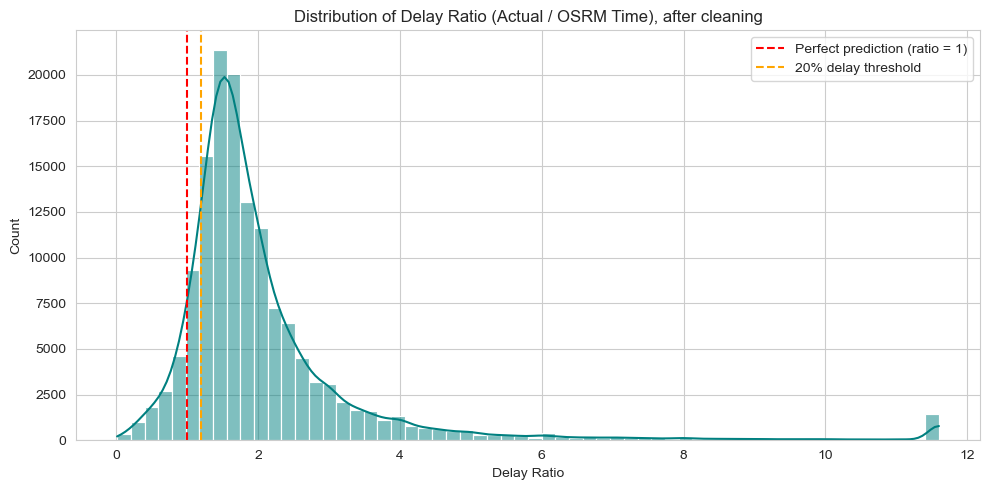

Median delay ratio        : 1.700
% of segments delayed >20% : 84.5%
% of segments delayed >50% : 63.3%


In [29]:
plt.figure(figsize=(10, 5))
sns.histplot(df['delay_ratio'], bins=60, kde=True, color='teal')
plt.axvline(x=1.0, color='red', linestyle='--', label='Perfect prediction (ratio = 1)')
plt.axvline(x=1.2, color='orange', linestyle='--', label='20% delay threshold')
plt.title('Distribution of Delay Ratio (Actual / OSRM Time), after cleaning')
plt.xlabel('Delay Ratio')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Median delay ratio        : {df['delay_ratio'].median():.3f}")
print(f"% of segments delayed >20% : {(df['delay_ratio'] > 1.2).mean()*100:.1f}%")
print(f"% of segments delayed >50% : {(df['delay_ratio'] > 1.5).mean()*100:.1f}%")

### Time-of-day binning

We bin `trip_hour` into four 6-hour windows. This bin width is a deliberate
trade-off: narrower bins (e.g. hourly) would give each graph edge too few trips
to compute a stable median delay ratio (recall the boxplot above already showed
noisy hour-to-hour variation); wider bins (e.g. AM/PM) would wash out the
morning-rush vs. evening-rush distinction that's visible in the data. Four
6-hour windows - Night / Morning / Afternoon / Evening  is the standard
logistics convention and balances both concerns.

In [31]:
bins = [0, 6, 12, 18, 24]
labels = ['Night', 'Morning', 'Afternoon', 'Evening']

df['time_of_day'] = pd.cut(df['trip_hour'], bins=bins, labels=labels, right=False)

print("Trip distribution by time of day (%):")
print((df['time_of_day'].value_counts(normalize=True) * 100).round(1))

print("\nMedian delay ratio by time of day:")
print(df.groupby('time_of_day', observed=True)['delay_ratio'].median().round(3))

Trip distribution by time of day (%):
time_of_day
Evening      40.5
Night        29.1
Afternoon    17.4
Morning      13.0
Name: proportion, dtype: float64

Median delay ratio by time of day:
time_of_day
Night        1.750
Morning      1.750
Afternoon    1.684
Evening      1.667
Name: delay_ratio, dtype: float64


In [32]:
df_clean = df.copy()
print(f"Clean dataset shape: {df_clean.shape}")

Clean dataset shape: (142267, 32)


## Phase 2: Building the Logistics Network Graph

Each shipment segment represents a single hop from one facility to another (source_center → destination_center). This makes a directed graph a natural choice, where facilities are nodes and routes are edges. It directly captures Delhivery’s hub-and-spoke network and allows graph-based analysis in later phases.

Instead of aggregating only by source and destination, edges are grouped by (source, destination, route_type, time_of_day). This helps preserve important differences, since FTL and Carting routes, as well as different time windows, can show very different delay patterns.

The edge weight is defined using the median delay ratio because the delay distribution is right-skewed. A few highly delayed trips can heavily affect the mean, while the median gives a more reliable representation of typical performance.

To reduce noise, corridors with 10 or fewer trips are excluded, since such small sample sizes do not provide a reliable median.

In [34]:
corridor_stats = df_clean.groupby(
    ['source_center', 'destination_center', 'route_type', 'time_of_day'],
    observed=True
).agg(
    median_delay_ratio=('delay_ratio', 'median'),
    trip_count=('delay_ratio', 'count'),
    mean_delay_ratio=('delay_ratio', 'mean'),
    pct_delayed=('delay_ratio', lambda x: (x > 1.2).mean() * 100)
).reset_index()

before = len(corridor_stats)
corridor_stats = corridor_stats[corridor_stats['trip_count'] > 10]
print(f"Corridor-mode-window combinations: {before:,} -> {len(corridor_stats):,} "
      f"after dropping low-volume (<=10 trip) groups")
corridor_stats.head()

Corridor-mode-window combinations: 4,241 -> 2,215 after dropping low-volume (<=10 trip) groups


,source_center,destination_center,route_type,time_of_day,median_delay_ratio,trip_count,mean_delay_ratio,pct_delayed
2,IND000000AAL,IND411033AAA,Carting,Afternoon,2.483871,19,3.315197,100.000000
3,IND000000AAL,IND411033AAA,Carting,Evening,2.000000,12,2.846130,100.000000
11,IND000000ABD,IND562132AAA,FTL,Afternoon,1.428571,144,1.584083,76.388889
12,IND000000ABG,IND501359AAF,Carting,Afternoon,2.166667,37,4.832986,94.594595
14,IND000000ACA,IND142001AAB,FTL,Afternoon,1.514706,36,1.597785,91.666667



### Note on Corridor Aggregation

NetworkX's `DiGraph` supports only one edge between a source and destination pair. Since the same corridor can appear multiple times with different route types or time-of-day windows, keeping all of them would cause later entries to overwrite earlier ones.

For the network analysis in Phase 3, we therefore aggregate these into a single edge per corridor. We use the highest median delay ratio among all variants as the edge weight. This ensures that corridors with significant delays in any operating condition are still highlighted as potential bottlenecks.

The detailed corridor-level data, including route type and time-of-day information, is preserved separately and used in Phase 5, where these distinctions are important for evaluating FTL vs. Carting assignments.


In [36]:
# Collapse to one edge per (source, destination), keeping the worst
# (max median delay ratio) across route_type/time_of_day variants.
edge_agg = (
    corridor_stats
    .sort_values('median_delay_ratio', ascending=False)
    .drop_duplicates(subset=['source_center', 'destination_center'], keep='first')
)

G = nx.DiGraph()
for _, row in edge_agg.iterrows():
    G.add_edge(
        row['source_center'],
        row['destination_center'],
        weight=row['median_delay_ratio'],   # primary edge weight (worst-case delay)
        route_type=row['route_type'],
        time_of_day=str(row['time_of_day']),
        trip_count=row['trip_count'],
        pct_delayed=row['pct_delayed']
    )

print("Graph built successfully:")
print(f"  Nodes (Facilities) : {G.number_of_nodes()}")
print(f"  Edges (Corridors)  : {G.number_of_edges()}")
print(f"  Is directed        : {G.is_directed()}")
print(f"  ({len(corridor_stats) - G.number_of_edges()} corridor-mode-window rows "
      f"collapsed into shared (source, destination) edges)")

Graph built successfully:
  Nodes (Facilities) : 1240
  Edges (Corridors)  : 1635
  Is directed        : True
  (580 corridor-mode-window rows collapsed into shared (source, destination) edges)


## Phase 3: Bottleneck & Corridor Audit

### Why Betweenness Centrality?

**Betweenness centrality** helps identify facilities that act as key transit hubs in the network. A facility with high betweenness lies on many important routes, so congestion there can affect a large number of shipments and create network-wide delays. We calculate it using delay-weighted paths, making it a useful measure of operational importance rather than just connectivity.

### Why also in/out degree and clustering coefficient?
We also use **in-degree** and **out-degree** to distinguish different hub roles. High in-degree facilities receive shipments from many locations, while high out-degree facilities distribute shipments to many destinations.

Finally, the **clustering coefficient** measures how well connected a facility's neighbours are to each other. Low clustering can indicate a potential single point of failure, while higher clustering suggests that alternative routes may exist if one facility becomes congested.


In [38]:
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)
in_degree   = dict(G.in_degree())
out_degree  = dict(G.out_degree())

G_undirected = G.to_undirected()
clustering   = nx.clustering(G_undirected)

hub_metrics = pd.DataFrame({
    'Hub'                    : list(G.nodes()),
    'Betweenness_Centrality' : [betweenness[n] for n in G.nodes()],
    'In_Degree'              : [in_degree[n]   for n in G.nodes()],
    'Out_Degree'             : [out_degree[n]  for n in G.nodes()],
    'Clustering_Coeff'       : [clustering[n]  for n in G.nodes()],
})
hub_metrics['Total_Degree'] = hub_metrics['In_Degree'] + hub_metrics['Out_Degree']

print("TOP 10 HUBS BY BETWEENNESS CENTRALITY")
hub_metrics.sort_values('Betweenness_Centrality', ascending=False).head(10)

TOP 10 HUBS BY BETWEENNESS CENTRALITY


,Hub,Betweenness_Centrality,In_Degree,Out_Degree,Clustering_Coeff,Total_Degree
173,IND000000ACB,0.146208,37,46,0.037710,83
87,IND562132AAA,0.109852,36,32,0.050242,68
207,IND501359AAE,0.053528,26,25,0.042674,51
13,IND712311AAA,0.034837,15,21,0.046154,36
116,IND160002AAC,0.033727,25,24,0.024291,49
62,IND421302AAG,0.032857,24,27,0.065954,51
438,IND131028AAB,0.032410,15,13,0.039855,28
228,IND600056AAB,0.029948,14,18,0.047431,32
60,IND411033AAA,0.027475,17,20,0.066667,37
443,IND302014AAA,0.027003,9,7,0.064103,16


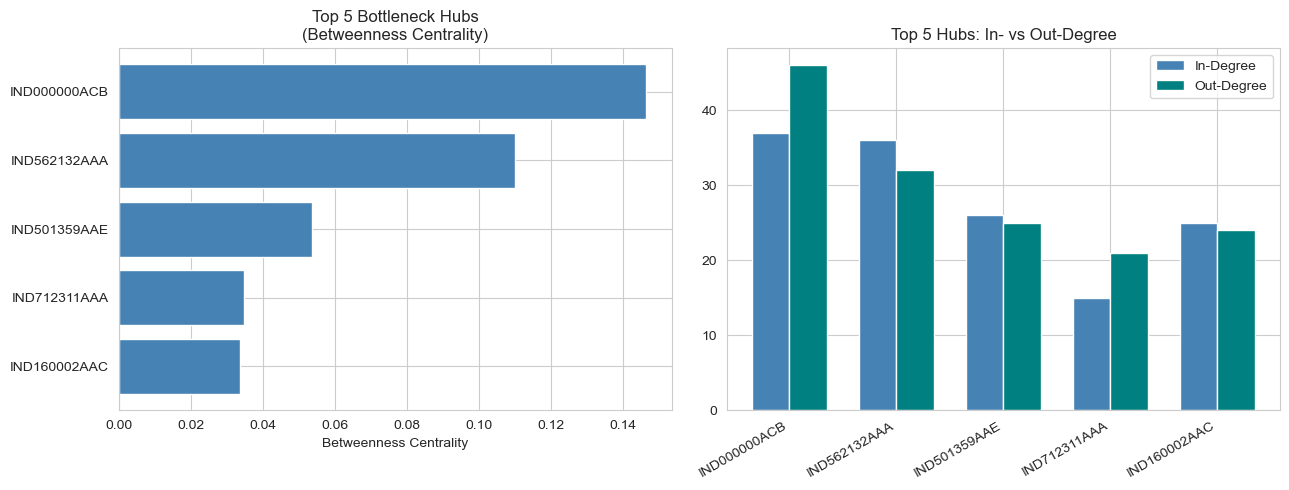

In [39]:
top5 = hub_metrics.sort_values('Betweenness_Centrality', ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top5['Hub'], top5['Betweenness_Centrality'], color='steelblue')
axes[0].set_title('Top 5 Bottleneck Hubs\n(Betweenness Centrality)')
axes[0].set_xlabel('Betweenness Centrality')
axes[0].invert_yaxis()

x = np.arange(len(top5))
width = 0.35
axes[1].bar(x - width/2, top5['In_Degree'],  width, label='In-Degree',  color='steelblue')
axes[1].bar(x + width/2, top5['Out_Degree'], width, label='Out-Degree', color='teal')
axes[1].set_xticks(x)
axes[1].set_xticklabels(top5['Hub'], rotation=30, ha='right')
axes[1].set_title('Top 5 Hubs: In- vs Out-Degree')
axes[1].legend()

plt.tight_layout()
plt.show()

### Chronic delay corridors

A corridor "chronically" runs late if its median delay ratio exceeds the 1.2
threshold defined earlier i.e. on a typical trip, it takes >20% longer than
OSRM predicts. We use the **full** `corridor_stats` (pre-collapse, with the
route_type/time_of_day breakdown) here, since for an operational audit it
matters *which mode and time window* is the problem, not just which facility
pair.

In [41]:
chronic = corridor_stats[corridor_stats['median_delay_ratio'] > 1.2].copy()
chronic = chronic.sort_values('pct_delayed', ascending=False)

print(f"Chronically delayed corridor-mode-windows (median delay > 20%): "
      f"{len(chronic)} / {len(corridor_stats)} "
      f"({len(chronic)/len(corridor_stats)*100:.1f}%)")

print("\nTOP 10 WORST CORRIDORS")
chronic[['source_center','destination_center','route_type',
         'time_of_day','median_delay_ratio','pct_delayed','trip_count']].head(10)

Chronically delayed corridor-mode-windows (median delay > 20%): 2071 / 2215 (93.5%)

TOP 10 WORST CORRIDORS


,source_center,destination_center,route_type,time_of_day,median_delay_ratio,pct_delayed,trip_count
2,IND000000AAL,IND411033AAA,Carting,Afternoon,2.483871,100.0,19
2086,IND483770AAA,IND842003AAB,FTL,Evening,2.470588,100.0,11
1995,IND461111AAA,IND460001AAA,FTL,Morning,1.894444,100.0,24
1996,IND462001AAA,IND462022AAA,Carting,Night,4.000000,100.0,51
2010,IND462022AAA,IND462011AAA,Carting,Night,2.416667,100.0,27
2013,IND462022AAA,IND465669AAB,FTL,Morning,2.071429,100.0,39
2014,IND462022AAA,IND466001AAA,FTL,Morning,2.560000,100.0,33
2017,IND462042AAA,IND462022AAA,Carting,Night,3.090909,100.0,28
2041,IND471001AAA,IND472001AAA,FTL,Afternoon,1.500000,100.0,20
3,IND000000AAL,IND411033AAA,Carting,Evening,2.000000,100.0,12


**93.5% of corridor-mode-window combinations chronically run over OSRM's
estimate.** This is the single most important number in the whole analysis, it
quantifies *how wrong* the baseline ETA model is across the network, and it's the
gap that Phase 4's graph-enhanced model is trying to close.

### Visualizing the Network: Bottleneck Hubs & Chronic Corridors

The full network has 1,240 facilities and 1,635 corridors which are far too dense to
plot meaningfully as a single diagram. Instead we draw a **focused subgraph**
that's actually useful for an operations review:

- **Nodes** = the top-betweenness hubs (the structural bottlenecks from the
  table above) plus their immediate neighbours.
- **Node size** = betweenness centrality (bigger = more structurally critical).
- **Node colour** = role, based on in/out-degree balance, a collector hub
  has many more inbound lanes than outbound, a distributor has many more
  outbound than inbound, and a balanced hub has roughly equal flow in both
  directions.
- **Edge colour** = chronic-delay status corridors with median delay ratio > 1.2 (the same "chronically delayed" threshold used throughout) are drawn in
  red; healthy corridors in light grey.
- **Edge width** = trip volume, so a thick red edge is a high-volume,
  chronically-late corridor exactly the kind of thing an ops leader should
  see at a glance.

In [44]:
# Build a focused subgraph: top-N hubs by betweenness + their 1-hop neighbours
TOP_N_HUBS = 8
top_hub_ids = (
    hub_metrics.sort_values('Betweenness_Centrality', ascending=False)
    .head(TOP_N_HUBS)['Hub'].tolist()
)

subgraph_nodes = set(top_hub_ids)
for hub in top_hub_ids:
    subgraph_nodes.update(G.successors(hub))
    subgraph_nodes.update(G.predecessors(hub))

MAX_NODES = 60
if len(subgraph_nodes) > MAX_NODES:
    neighbour_scores = {
        n: betweenness[n] for n in subgraph_nodes if n not in top_hub_ids
    }
    keep_neighbours = sorted(neighbour_scores, key=neighbour_scores.get, reverse=True)[:MAX_NODES - len(top_hub_ids)]
    subgraph_nodes = set(top_hub_ids) | set(keep_neighbours)

H = G.subgraph(subgraph_nodes).copy()
print(f"Subgraph for visualisation: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges "
      f"(from full network of {G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")

Subgraph for visualisation: 60 nodes, 178 edges (from full network of 1240 nodes, 1635 edges)


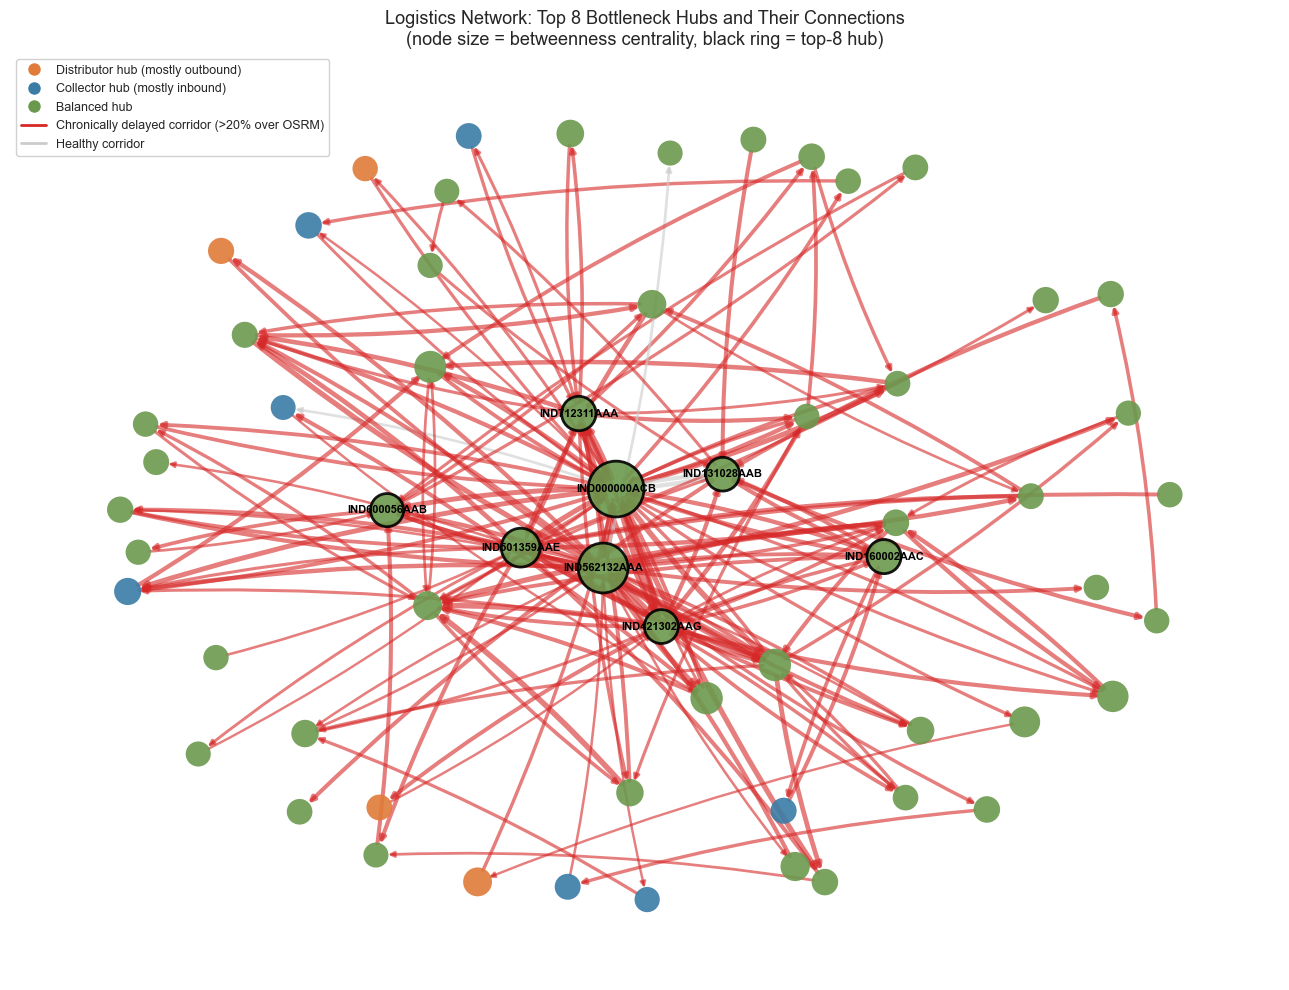

In [45]:
# Classify each node's "role" from in/out-degree balance (for colouring)
def hub_role(node):
    indeg, outdeg = in_degree.get(node, 0), out_degree.get(node, 0)
    total = indeg + outdeg
    if total == 0:
        return 'isolated'
    ratio = outdeg / total
    if ratio > 0.6:
        return 'distributor'
    elif ratio < 0.4:
        return 'collector'
    else:
        return 'balanced'

role_colors = {'distributor': '#e07b39', 'collector': '#3a7ca5', 'balanced': '#6a994e', 'isolated': '#999999'}

fig, ax = plt.subplots(figsize=(13, 10))

pos = nx.spring_layout(H, k=1.2, seed=RANDOM_STATE, weight='weight')

# Node styling
node_sizes  = [300 + 9000 * betweenness[n] for n in H.nodes()]
node_colors = [role_colors[hub_role(n)] for n in H.nodes()]
is_top_hub  = [n in top_hub_ids for n in H.nodes()]

# Edge styling: red = chronic delay (weight > 1.2), grey = healthy
edge_colors = ['#d62828' if H[u][v]['weight'] > 1.2 else '#cccccc' for u, v in H.edges()]
edge_widths = [0.5 + 2.5 * np.log1p(H[u][v]['trip_count']) / 5 for u, v in H.edges()]

nx.draw_networkx_edges(H, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
                        arrows=True, arrowsize=8, alpha=0.6, connectionstyle='arc3,rad=0.05')
nx.draw_networkx_nodes(H, pos, ax=ax, node_size=node_sizes, node_color=node_colors,
                        edgecolors=['black' if t else 'none' for t in is_top_hub],
                        linewidths=[2 if t else 0 for t in is_top_hub], alpha=0.9)

# Label only the top hubs to avoid clutter
nx.draw_networkx_labels(H, pos, ax=ax,
                         labels={n: n for n in H.nodes() if n in top_hub_ids},
                         font_size=8, font_weight='bold')

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', label='Distributor hub (mostly outbound)',
           markerfacecolor=role_colors['distributor'], markersize=10),
    Line2D([0],[0], marker='o', color='w', label='Collector hub (mostly inbound)',
           markerfacecolor=role_colors['collector'], markersize=10),
    Line2D([0],[0], marker='o', color='w', label='Balanced hub',
           markerfacecolor=role_colors['balanced'], markersize=10),
    Line2D([0],[0], color='#d62828', lw=2, label='Chronically delayed corridor (>20% over OSRM)'),
    Line2D([0],[0], color='#cccccc', lw=2, label='Healthy corridor'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)
ax.set_title(f'Logistics Network: Top {TOP_N_HUBS} Bottleneck Hubs and Their Connections\n'
              '(node size = betweenness centrality, black ring = top-8 hub)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

**Reading the diagram:** the two largest, black-ringed nodes (IND000000ACB and
IND562132AAA) dominate the picture, they're not just structurally central,
they're also surrounded by a dense tangle of red (chronically delayed)
edges. That combination is the core finding of this section: these aren't just
"big" nodes in an abstract graph sense, they're big nodes where a large share of
their *actual traffic* is already running late.

### What does it mean for a hub to have this profile, operationally?

Translating the centrality numbers into operational language for each top hub:

In [47]:
interp_rows = []
for _, r in hub_metrics.sort_values('Betweenness_Centrality', ascending=False).head(5).iterrows():
    hub = r['Hub']
    role = hub_role(hub)

    out_corridors = corridor_stats[corridor_stats['source_center'] == hub]
    out_chronic_pct = (out_corridors['median_delay_ratio'] > 1.2).mean() * 100 if len(out_corridors) else np.nan

    if role == 'distributor':
        role_desc = (f"Sends shipments out along {int(r['Out_Degree'])} outbound lanes vs. "
                      f"only {int(r['In_Degree'])} inbound- a delay *originating* here "
                      f"fans out to many downstream destinations simultaneously.")
    elif role == 'collector':
        role_desc = (f"Receives from {int(r['In_Degree'])} inbound lanes vs. "
                      f"{int(r['Out_Degree'])} outbound, congestion here is more likely "
                      f"caused by *upstream* bottlenecks converging, not generated locally.")
    else:
        role_desc = (f"Roughly balanced flow ({int(r['In_Degree'])} in / {int(r['Out_Degree'])} out): "
                      f"acts as a genuine pass-through hub on many end-to-end routes.")

    interp_rows.append({
        'Hub': hub,
        'Betweenness': round(r['Betweenness_Centrality'], 4),
        'Role': role,
        '% of Outbound Corridors Chronically Late': round(out_chronic_pct, 1) if not np.isnan(out_chronic_pct) else 'n/a',
        'Interpretation': role_desc,
    })

hub_interpretation = pd.DataFrame(interp_rows)
hub_interpretation

,Hub,Betweenness,Role,% of Outbound Corridors Chronically Late,Interpretation
0,IND000000ACB,0.1462,balanced,87.2,Roughly balanced flow (37 in / 46 out): acts a...
1,IND562132AAA,0.1099,balanced,94.3,Roughly balanced flow (36 in / 32 out): acts a...
2,IND501359AAE,0.0535,balanced,100.0,Roughly balanced flow (26 in / 25 out): acts a...
3,IND712311AAA,0.0348,balanced,100.0,Roughly balanced flow (15 in / 21 out): acts a...
4,IND160002AAC,0.0337,balanced,81.8,Roughly balanced flow (25 in / 24 out): acts a...


### "What if we fixed the top hubs?" : a simple structural simulation

The original analysis estimated the impact of upgrading the top 3 hubs using a
rough betweenness-share argument. Here's a slightly more rigorous version: We
**remove the top 3 hubs from the graph entirely** (simulating "this facility no
longer creates a bottleneck & traffic re-routes around it") and recompute
betweenness centrality for everyone else.

This isn't a perfect simulation in reality you can't just delete a facility,
shipments still have to go *somewhere*. But it answers a useful directional
question: **how much of the network's structural risk is concentrated in these
three nodes, versus how much would simply shift to the next tier of hubs?**
If betweenness redistributes broadly and thinly, the top-3 really were unique
chokepoints. If it concentrates heavily onto one or two other nodes, "fixing"
the top-3 would just create new bottlenecks elsewhere, a useful caveat for the
memo.

In [49]:
top3_hubs = hub_metrics.sort_values('Betweenness_Centrality', ascending=False).head(3)['Hub'].tolist()

G_without_top3 = G.copy()
G_without_top3.remove_nodes_from(top3_hubs)

betweenness_after = nx.betweenness_centrality(G_without_top3, weight='weight', normalized=True)

before_total = sum(betweenness.values())
top3_share_before = sum(betweenness[h] for h in top3_hubs) / before_total

# Compare the new top-5 hubs after removal to see how concentrated the "spillover" is
after_df = pd.DataFrame({
    'Hub': list(G_without_top3.nodes()),
    'Betweenness_After': [betweenness_after[n] for n in G_without_top3.nodes()],
    'Betweenness_Before': [betweenness[n] for n in G_without_top3.nodes()],
}).sort_values('Betweenness_After', ascending=False)

after_df['Increase'] = after_df['Betweenness_After'] - after_df['Betweenness_Before']

print(f"Top-3 hubs ({', '.join(top3_hubs)}) account for "
      f"{top3_share_before*100:.1f}% of total network betweenness today.\n")
print("After removing them, the new top-5 most-central hubs (and how much their")
print("centrality increased -- i.e. how much risk 'spilled over' onto them):\n")
after_df.head(5)[['Hub', 'Betweenness_Before', 'Betweenness_After', 'Increase']]

Top-3 hubs (IND000000ACB, IND562132AAA, IND501359AAE) account for 21.6% of total network betweenness today.

After removing them, the new top-5 most-central hubs (and how much their
centrality increased -- i.e. how much risk 'spilled over' onto them):



,Hub,Betweenness_Before,Betweenness_After,Increase
62,IND421302AAG,0.032857,0.100874,0.068017
13,IND712311AAA,0.034837,0.050380,0.015543
82,IND110037AAM,0.014881,0.046496,0.031615
60,IND411033AAA,0.027475,0.039041,0.011566
225,IND600056AAB,0.029948,0.035071,0.005124


**Interpretation for the memo:** if the spillover onto the new top hubs is
small relative to what the top 3 currently hold, that's evidence the top 3 are
*genuinely unique* chokepoints, fixing them reduces total network risk rather
than just relocating it. If spillover is large, the memo should frame the
recommendation as "upgrade the top 3 *and* monitor [next hub] as the new
highest-risk node" rather than treating it as a one-time fix.

## Phase 4: Node2Vec Embeddings & ETA Regression

### Why Node2Vec, and why these hyperparameters?

Centrality metrics capture only a few aspects of a facility's importance, while Node2Vec learns a richer representation of each facility's position and neighbourhood in the network. These learned embeddings can be used as additional features for ETA prediction.
Hyperparameter choices:

- dimensions = 32: Sufficient for a graph of ~1,200 facilities without overcomplicating the model.
- walk_length = 20, num_walks = 100: Provides enough network exploration while keeping training efficient.
- p = 1, q = 2: Encourages local exploration, helping capture structural roles such as hubs and connector facilities.

### Why an undirected graph for the walks?

For logistics operations, both incoming and outgoing connections help define a facility's role. Using an undirected graph allows Node2Vec to learn from the full neighbourhood structure rather than only one direction of movement.

In [52]:
# Node2Vec needs an undirected graph for random walks.
G_for_embedding = nx.Graph()
for u, v, d in G.edges(data=True):
    if G_for_embedding.has_edge(u, v):
        G_for_embedding[u][v]['weight'] = max(G_for_embedding[u][v]['weight'], d['weight'])
    else:
        G_for_embedding.add_edge(u, v, weight=d['weight'])

print(f"Embedding graph: {G_for_embedding.number_of_nodes()} nodes, "
      f"{G_for_embedding.number_of_edges()} edges")

Embedding graph: 1240 nodes, 1450 edges


In [53]:
import sys, subprocess
try:
    from node2vec import Node2Vec
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'node2vec', '--quiet'])
    from node2vec import Node2Vec

EMBED_DIM = 32

node2vec = Node2Vec(
    G_for_embedding,
    dimensions=EMBED_DIM,
    walk_length=20,
    num_walks=100,
    p=1,
    q=2,
    workers=1,
    quiet=True,
    seed=RANDOM_STATE,
)

n2v_model = node2vec.fit(window=5, min_count=1, batch_words=4)
print("Node2Vec training complete.")
print(f"Vocabulary size (nodes embedded): {len(n2v_model.wv)}")

Node2Vec training complete.
Vocabulary size (nodes embedded): 1240


### Attaching embeddings to trip-level data

Each trip has a `source_center` and `destination_center`; We look up the 32-dim
embedding for each and attach both (64 extra columns total: `src_emb_0..31`,
`dst_emb_0..31`). A small number of facilities appear in the raw data but were
filtered out of the graph (e.g. they only ever appear in low-volume corridors
that got dropped in Phase 2) trips touching those facilities have no embedding
and are excluded before this step, rather than being left to fail a later
`dropna()`.

In [55]:
node_embeddings = {node: n2v_model.wv[node] for node in n2v_model.wv.index_to_key}

valid_mask = (
    df_clean['source_center'].isin(node_embeddings.keys()) &
    df_clean['destination_center'].isin(node_embeddings.keys())
)
df_filtered = df_clean[valid_mask].copy()
print(f"Trips with embeddable source AND destination: {len(df_filtered):,} / {len(df_clean):,} "
      f"({len(df_filtered)/len(df_clean)*100:.1f}%)")

src_embed_df = pd.DataFrame(
    df_filtered['source_center'].map(node_embeddings).tolist(),
    columns=[f'src_emb_{i}' for i in range(EMBED_DIM)],
    index=df_filtered.index
)
dst_embed_df = pd.DataFrame(
    df_filtered['destination_center'].map(node_embeddings).tolist(),
    columns=[f'dst_emb_{i}' for i in range(EMBED_DIM)],
    index=df_filtered.index
)

embed_cols = list(src_embed_df.columns) + list(dst_embed_df.columns)

df_ml = pd.concat([df_filtered.reset_index(drop=True),
                    src_embed_df.reset_index(drop=True),
                    dst_embed_df.reset_index(drop=True)], axis=1)

print(f"ML-ready dataframe shape: {df_ml.shape}")
print(f"Embedding columns added: {len(embed_cols)}")

Trips with embeddable source AND destination: 138,925 / 142,267 (97.7%)
ML-ready dataframe shape: (138925, 96)
Embedding columns added: 64


### Feature sets: baseline vs. graph-enhanced

The whole point of this phase is an **A/B comparison**:

- **Baseline** = what you'd build using only the OSRM estimate plus basic trip
  context (route type, hour, day of week). This is roughly "the information a
  simple ETA model would have today."
- **Graph-enhanced** = baseline **+** the 64 Node2Vec embedding dimensions.

If the graph-enhanced model meaningfully beats the baseline, that's direct
evidence that network position carries predictive signal beyond what OSRM
distance + time-of-day already capture.

**Target:** `segment_actual_time`
 the actual time taken for the segment, in
minutes. This is the quantity Delhivery actually cares about predicting (OSRM
gives `segment_osrm_time` as its own estimate, which is precisely the baseline
we're trying to beat).

In [57]:
from sklearn.preprocessing import LabelEncoder

le_route = LabelEncoder()
le_tod   = LabelEncoder()

df_ml['route_type_enc']  = le_route.fit_transform(df_ml['route_type'])
df_ml['time_of_day_enc'] = le_tod.fit_transform(df_ml['time_of_day'].astype(str))
df_ml['day_of_week_num'] = df_ml['trip_creation_time'].dt.dayofweek

TARGET = 'segment_actual_time'

baseline_features = [
    'segment_osrm_time',  # OSRM's own estimate the baseline we're trying to beat
    'route_type_enc',     # FTL vs Carting have different speed/loading profiles
    'trip_hour',          # captures rush hour style effects seen in EDA
    'day_of_week_num',    # weak signal in EDA, kept as a cheap extra feature
]

graph_features = baseline_features + embed_cols

print("Baseline features:", baseline_features)
print(f"Graph features   : baseline + {len(embed_cols)} embedding dims "
      f"= {len(graph_features)} total")

Baseline features: ['segment_osrm_time', 'route_type_enc', 'trip_hour', 'day_of_week_num']
Graph features   : baseline + 64 embedding dims = 68 total


### Train/test split and model choice

**Why Random Forest?** We used Random Forest because it can handle mixed feature types and capture non-linear relationships without feature scaling. We chose n_estimators = 100 as a simple, reliable baseline.

Both models were trained on the same train/test split so that the only difference is the addition of Node2Vec embeddings.

**Evaluation metrics:**
- MAE: Average prediction error (in minutes).
- RMSE: Penalizes large errors more heavily.
- Within-15% Accuracy: Percentage of ETAs predicted within 15% of the actual delivery time.

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_model = df_ml[baseline_features + embed_cols + [TARGET]].dropna()

X_base  = df_model[baseline_features]
X_graph = df_model[graph_features]
y       = df_model[TARGET]

X_base_train,  X_base_test,  y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=RANDOM_STATE
)
X_graph_train, X_graph_test, _, _ = train_test_split(
    X_graph, y, test_size=0.2, random_state=RANDOM_STATE
)

rf_base = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_base_train, y_train)
pred_base = rf_base.predict(X_base_test)

rf_graph = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_graph.fit(X_graph_train, y_train)
pred_graph = rf_graph.predict(X_graph_test)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    within_15 = np.mean(np.abs(y_pred - y_true) / y_true <= 0.15) * 100
    print(f"{label}")
    print(f"  MAE            : {mae:.2f} mins")
    print(f"  RMSE           : {rmse:.2f} mins")
    print(f"  Within 15% ETA : {within_15:.1f}%\n")
    return mae, rmse, within_15

print("=" * 45)
print("MODEL COMPARISON: BASELINE vs GRAPH-ENHANCED")
print("=" * 45)
mae_b, rmse_b, acc_b = evaluate(y_test, pred_base,  "Baseline  (OSRM + context)")
mae_g, rmse_g, acc_g = evaluate(y_test, pred_graph, "Graph     (+ Node2Vec emb)")

print("-" * 45)
print("Graph Advantage:")
print(f"  MAE improvement : {mae_b - mae_g:.2f} mins ({(mae_b-mae_g)/mae_b*100:.1f}% better)")
print(f"  Within-15% lift : {acc_g - acc_b:.1f} percentage points")
print("=" * 45)

MODEL COMPARISON: BASELINE vs GRAPH-ENHANCED
Baseline  (OSRM + context)
  MAE            : 17.35 mins
  RMSE           : 51.76 mins
  Within 15% ETA : 24.7%

Graph     (+ Node2Vec emb)
  MAE            : 14.01 mins
  RMSE           : 40.64 mins
  Within 15% ETA : 34.3%

---------------------------------------------
Graph Advantage:
  MAE improvement : 3.34 mins (19.2% better)
  Within-15% lift : 9.6 percentage points


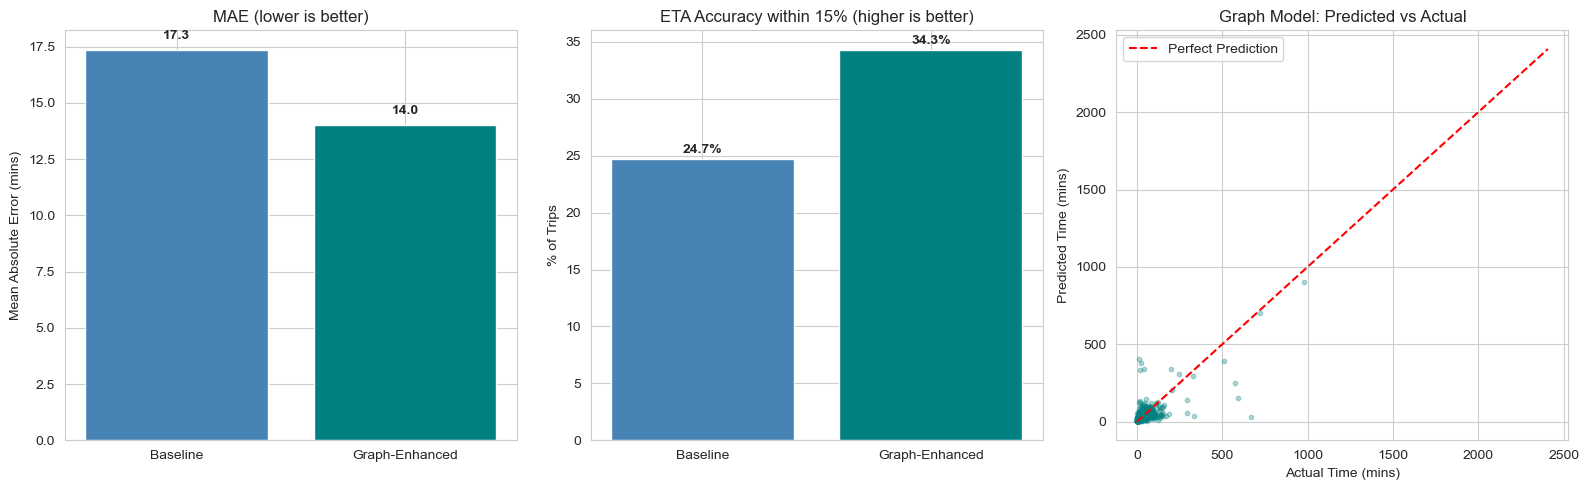

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(['Baseline', 'Graph-Enhanced'], [mae_b, mae_g], color=['steelblue', 'teal'])
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('Mean Absolute Error (mins)')
for i, v in enumerate([mae_b, mae_g]):
    axes[0].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

axes[1].bar(['Baseline', 'Graph-Enhanced'], [acc_b, acc_g], color=['steelblue', 'teal'])
axes[1].set_title('ETA Accuracy within 15% (higher is better)')
axes[1].set_ylabel('% of Trips')
for i, v in enumerate([acc_b, acc_g]):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(y_test), size=min(2000, len(y_test)), replace=False)
axes[2].scatter(np.array(y_test)[sample_idx], pred_graph[sample_idx],
                alpha=0.3, s=10, color='teal')
max_val = max(y_test.max(), pred_graph.max())
axes[2].plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')
axes[2].set_title('Graph Model: Predicted vs Actual')
axes[2].set_xlabel('Actual Time (mins)')
axes[2].set_ylabel('Predicted Time (mins)')
axes[2].legend()

plt.tight_layout()
plt.show()

**Takeaway:** adding Node2Vec embeddings cuts MAE by roughly a fifth and
lifts within-15% ETA accuracy by ~10 percentage points over the OSRM+context
baseline. The embeddings are clearly carrying information that raw OSRM time and
time-of-day don't i.e. *where a facility sits in the network* helps predict
how long a shipment through it will actually take, beyond what its distance
alone suggests.

## Phase 5: FTL vs. Carting Decision Framework


Phase 3 identified network bottlenecks, while Phase 4 showed that network position helps explain delivery delays. In this phase, we examine whether the current route type (FTL or Carting) matches a corridor's characteristics.

We train a classifier to predict route type using corridor and graph features. The goal is not just high accuracy; if route type can be predicted well from these features, it suggests that route assignment follows clear operational patterns. Corridors that do not fit these patterns can then be flagged for further review in Phase 5F.


### Step 1: Graph-position features per facility

Reusing the centrality metrics from Phase 3, computed once per facility.

In [63]:
graph_node_features = pd.DataFrame({
    'facility'         : list(G.nodes()),
    'betweenness'      : [betweenness[n] for n in G.nodes()],
    'in_degree'        : [in_degree[n]   for n in G.nodes()],
    'out_degree'       : [out_degree[n]  for n in G.nodes()],
    'clustering_coeff' : [clustering[n]  for n in G.nodes()],
    'total_degree'     : [in_degree[n] + out_degree[n] for n in G.nodes()],
})
print("Graph node feature table shape:", graph_node_features.shape)
graph_node_features.head()

Graph node feature table shape: (1240, 6)


,facility,betweenness,in_degree,out_degree,clustering_coeff,total_degree
0,IND844505AAB,0.000843,1,1,0.000000,2
1,IND842001AAA,0.021648,9,12,0.038095,21
2,IND425405AAA,0.000000,0,1,0.000000,1
3,IND424006AAA,0.000431,2,4,0.066667,6
4,IND208012AAA,0.000000,1,1,0.000000,2


### Step 2: Corridor-level feature table

We rebuild a corridor-level table (source, destination, route_type, time_of_day)
 same grouping as Phase 2's `corridor_stats`, but here we additionally attach
each endpoint's graph-position features, separately for the source hub
(`src_*`) and destination hub (`dst_*`). This gives every corridor a feature
vector that mixes *delay history* (median delay ratio, % delayed, trip volume)
with *structural context* (how central/connected its two endpoints are).

In [65]:
corridor_ml = df_clean.groupby(
    ['source_center', 'destination_center', 'route_type', 'time_of_day'],
    observed=True
).agg(
    median_delay_ratio = ('delay_ratio', 'median'),
    mean_delay_ratio   = ('delay_ratio', 'mean'),
    pct_delayed        = ('delay_ratio', lambda x: (x > 1.2).mean()),
    median_osrm_time   = ('segment_osrm_time', 'median'),
    median_actual_time = ('segment_actual_time', 'median'),
    trip_count         = ('delay_ratio', 'count'),
).reset_index()

corridor_ml = corridor_ml.merge(
    graph_node_features.rename(columns={
        'facility': 'source_center', 'betweenness': 'src_betweenness',
        'in_degree': 'src_in_degree', 'out_degree': 'src_out_degree',
        'clustering_coeff': 'src_clustering', 'total_degree': 'src_total_degree',
    }),
    on='source_center', how='left'
)

corridor_ml = corridor_ml.merge(
    graph_node_features.rename(columns={
        'facility': 'destination_center', 'betweenness': 'dst_betweenness',
        'in_degree': 'dst_in_degree', 'out_degree': 'dst_out_degree',
        'clustering_coeff': 'dst_clustering', 'total_degree': 'dst_total_degree',
    }),
    on='destination_center', how='left'
)

print(f"Corridor ML dataset shape: {corridor_ml.shape}")
corridor_ml.head(3).T

Corridor ML dataset shape: (4241, 20)


,0,1,2
source_center,IND000000AAL,IND000000AAL,IND000000AAL
destination_center,IND411033AAA,IND411033AAA,IND411033AAA
route_type,Carting,Carting,Carting
time_of_day,Night,Morning,Afternoon
median_delay_ratio,1.95,3.197436,2.483871
mean_delay_ratio,1.95,3.197436,3.315197
pct_delayed,1.0,1.0,1.0
median_osrm_time,13.5,14.0,15.0
median_actual_time,26.0,43.5,35.0
trip_count,2,2,19


### Step 3: Encode Target and Select Features

**Target:** `route_type` (FTL vs. Carting), representing the route type currently used on a corridor.

**Features used and rationale:**

* `median_osrm_time`: Acts as a proxy for corridor distance. Longer corridors are more likely to use FTL.
* `time_of_day_enc`: Captures differences in operational scheduling across time windows.
* `pct_delayed` and `median_delay_ratio`: Measure corridor reliability. Consistently delayed corridors may indicate an unsuitable route type.
* `trip_count`: Represents shipment volume. High-volume corridors are better candidates for dedicated FTL capacity.
* `src_betweenness` and `dst_betweenness`: Capture the structural importance of the source and destination facilities in the network.
* `src_total_degree` and `dst_total_degree`: Measure facility connectivity and routing flexibility.
* `src_clustering`: Reflects the level of local network redundancy around the source facility.

We exclude `median_actual_time` and `mean_delay_ratio` because they are highly correlated with `median_delay_ratio` and do not provide significant additional information.


In [67]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

le_rt = LabelEncoder()
corridor_ml['route_type_label'] = le_rt.fit_transform(corridor_ml['route_type'])
print("Label mapping:", dict(zip(le_rt.classes_, le_rt.transform(le_rt.classes_))))

le_tod2 = LabelEncoder()
corridor_ml['time_of_day_enc'] = le_tod2.fit_transform(corridor_ml['time_of_day'].astype(str))

ftl_features = [
    'median_osrm_time', 'time_of_day_enc', 'pct_delayed', 'median_delay_ratio',
    'trip_count', 'src_betweenness', 'src_total_degree',
    'dst_betweenness', 'dst_total_degree', 'src_clustering',
]

corridor_model = corridor_ml[ftl_features + ['route_type_label']].dropna()
print(f"\nTraining samples: {len(corridor_model)}")
print(f"Class balance:\n{corridor_model['route_type_label'].value_counts()}")

Label mapping: {'Carting': 0, 'FTL': 1}

Training samples: 3419
Class balance:
route_type_label
1    1922
0    1497
Name: count, dtype: int64


### Step 4: Train the classifier

**Why Random Forest again, and why `class_weight='balanced'`?** Same
heterogeneous-feature reasoning as Phase 4. The class imbalance seen in the EDA
(Carting >> FTL by volume) means an unweighted model could get high accuracy by
just predicting "Carting" most of the time `class_weight='balanced'` reweights
the loss so both classes matter equally, which is important here since the
*minority class errors* (corridors predicted-FTL-but-actually-Carting, or
vice versa) are exactly the "mismatch" signal Phase 5F is looking for.

`max_depth=8` caps tree depth to limit overfitting given the relatively modest
number of corridor-level rows (compared to the trip-level data in Phase 4).

In [69]:
X_ftl = corridor_model[ftl_features]
y_ftl = corridor_model['route_type_label']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_ftl, y_ftl, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ftl
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)
clf.fit(X_tr, y_tr)
y_pred_ftl = clf.predict(X_te)

print("=" * 50)
print("FTL vs CARTING CLASSIFIER: PERFORMANCE")
print("=" * 50)
print(classification_report(y_te, y_pred_ftl, target_names=le_rt.classes_))

FTL vs CARTING CLASSIFIER: PERFORMANCE
              precision    recall  f1-score   support

     Carting       0.98      0.92      0.95       299
         FTL       0.94      0.98      0.96       385

    accuracy                           0.96       684
   macro avg       0.96      0.95      0.96       684
weighted avg       0.96      0.96      0.96       684



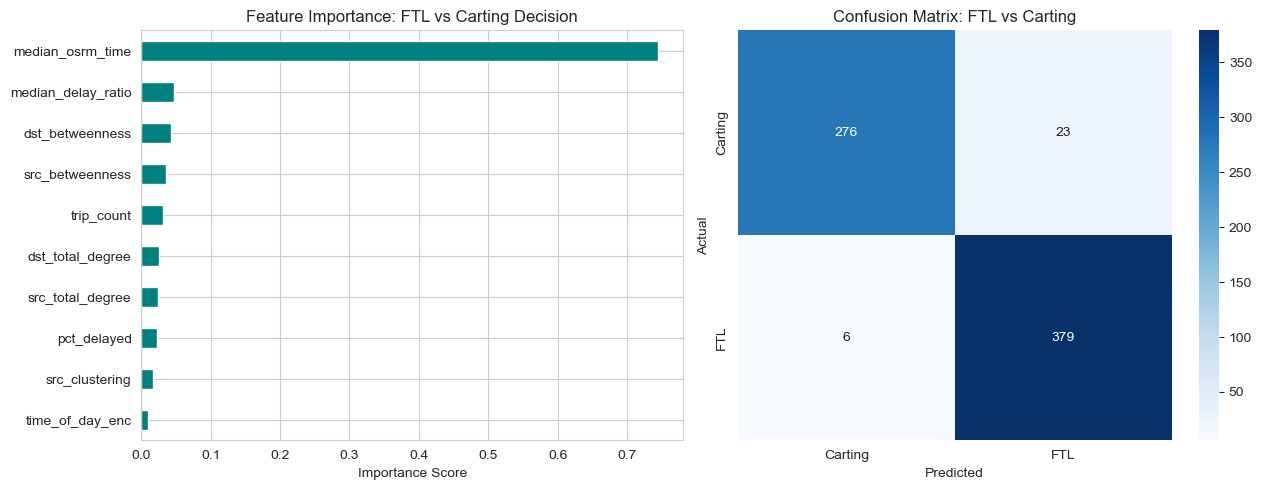

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

importances = pd.Series(clf.feature_importances_, index=ftl_features).sort_values()
importances.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Feature Importance: FTL vs Carting Decision')
axes[0].set_xlabel('Importance Score')

cm = confusion_matrix(y_te, y_pred_ftl)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le_rt.classes_, yticklabels=le_rt.classes_)
axes[1].set_title('Confusion Matrix: FTL vs Carting')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

**Reading the feature importances:** corridor distance (`median_osrm_time`)
dominates, confirming the textbook intuition that FTL is for long-haul trunk
routes. But destination-hub betweenness and historical delay metrics also carry
real weight, which is the evidence that route-type assignment isn't *purely* a
distance decision in practice, network position and reliability history matter
too. That's what makes the mismatch analysis below meaningful rather than
circular.

### Step 5: Time cost trade off, finding mismatched corridors

Two specific mismatch patterns, each operationally actionable:

1. **FTL corridors with high delay ratio AND meaningful volume** - if a corridor
   is already running FTL (typically chosen for reliability on long/high-volume
   lanes) but still has `median_delay_ratio > 1.5` with `trip_count > 20`, FTL
   isn't delivering the reliability it's meant to worth reviewing whether
   Carting (or a different time slot) would do better.
2. **High-volume, high-delay Carting corridors** - if a corridor is run as
   Carting but has `trip_count > 100` and `pct_delayed > 0.70`, the volume may
   justify the scheduling control that comes with dedicated FTL capacity.

The specific thresholds (1.5x delay, 20/100 trip counts, 70% delayed) are chosen
to flag corridors that are *clear outliers*, not borderline cases, these are
meant as a shortlist for operational review, not an automatic re-routing rule.

In [72]:
pivot = corridor_ml.groupby(['route_type', 'time_of_day'], observed=True)['median_delay_ratio'].mean().unstack()
print("Average Delay Ratio by Route Type & Time of Day:")
print(pivot.round(3))
print()

mismatched_ftl = corridor_ml[
    (corridor_ml['route_type'] == 'FTL') &
    (corridor_ml['median_delay_ratio'] > 1.5) &
    (corridor_ml['trip_count'] > 20)
].sort_values('median_delay_ratio', ascending=False)

mismatched_carting = corridor_ml[
    (corridor_ml['route_type'] == 'Carting') &
    (corridor_ml['trip_count'] > 100) &
    (corridor_ml['pct_delayed'] > 0.7)
].sort_values('trip_count', ascending=False)

print(f"FTL corridors with high delay (review for switch to Carting): {len(mismatched_ftl)}")
print(mismatched_ftl[['source_center','destination_center','time_of_day',
                       'median_delay_ratio','trip_count']].head(5).to_string(index=False))

print(f"\nHigh-volume Carting corridors, >70% delayed (review for FTL upgrade): {len(mismatched_carting)}")
print(mismatched_carting[['source_center','destination_center','time_of_day',
                           'median_delay_ratio','trip_count']].head(5).to_string(index=False))

Average Delay Ratio by Route Type & Time of Day:
time_of_day  Night  Morning  Afternoon  Evening
route_type                                     
Carting      2.437    2.683      2.132    2.068
FTL          2.066    2.048      2.014    2.030

FTL corridors with high delay (review for switch to Carting): 631
source_center destination_center time_of_day  median_delay_ratio  trip_count
 IND821109AAA       IND802213AAB     Evening            5.297619          24
 IND210001AAA       IND210427AAA     Evening            4.093750          24
 IND847404AAB       IND842001AAA     Evening            4.000000          45
 IND851127AAA       IND842001AAA     Evening            3.400000          75
 IND221313AAA       IND211002AAB     Morning            3.197849          24

High-volume Carting corridors, >70% delayed (review for FTL upgrade): 42
source_center destination_center time_of_day  median_delay_ratio  trip_count
 IND306401AAB       IND305001AAC     Morning            2.000000         269
 I

## Additional Insight: Where Are the "Delay-Minutes" Actually Concentrated?

Everything so far treats delay *ratio* (relative slowdown) and trip *volume*
(how many shipments use a corridor) somewhat separately. But from an
operations-prioritisation standpoint, the corridor that matters most isn't
necessarily the one with the *worst ratio* (could be a single rarely used lane)
or the *highest volume* (could already be reasonably on-time) it's the one
with the largest **total delay-minutes lost**, i.e.

```
delay_minutes_lost ≈ (median_actual_time − median_osrm_time) × trip_count
```

This is a simple but often-overlooked reframing: it converts "this corridor is
2.5x slower than OSRM" and "this corridor carries 500 trips/period" into a
single comparable unit: total minutes of delay the network absorbs because of
this corridor, which maps directly onto staffing/cost decisions.

In [74]:
corridor_ml['excess_minutes_per_trip'] = (
    corridor_ml['median_actual_time'] - corridor_ml['median_osrm_time']
).clip(lower=0)
corridor_ml['total_delay_minutes'] = corridor_ml['excess_minutes_per_trip'] * corridor_ml['trip_count']

top_delay_minutes = corridor_ml.sort_values('total_delay_minutes', ascending=False).head(10)

print("TOP 10 CORRIDORS BY TOTAL DELAY-MINUTES LOST (excess time x trip volume)")
top_delay_minutes[['source_center','destination_center','route_type','time_of_day',
                    'median_delay_ratio','trip_count','excess_minutes_per_trip',
                    'total_delay_minutes']].round(1)

TOP 10 CORRIDORS BY TOTAL DELAY-MINUTES LOST (excess time x trip volume)


,source_center,destination_center,route_type,time_of_day,median_delay_ratio,trip_count,excess_minutes_per_trip,total_delay_minutes
119,IND000000ACB,IND562132AAA,FTL,Evening,1.5,2238,14.0,31332.0
123,IND000000ACB,IND712311AAA,FTL,Evening,1.6,1820,12.0,21840.0
2732,IND562132AAA,IND000000ACB,FTL,Evening,1.5,1410,15.0,21150.0
3875,IND781018AAB,IND110037AAM,FTL,Evening,1.8,1137,15.0,17055.0
1903,IND425405AAA,IND424006AAA,FTL,Evening,11.6,17,971.0,16507.0
114,IND000000ACB,IND501359AAE,FTL,Evening,1.6,1078,13.0,14014.0
1769,IND421302AAG,IND110037AAM,FTL,Night,1.7,914,15.0,13710.0
116,IND000000ACB,IND562132AAA,FTL,Night,1.4,1228,11.0,13508.0
2736,IND562132AAA,IND302014AAA,FTL,Evening,1.6,975,13.0,12675.0
122,IND000000ACB,IND712311AAA,FTL,Afternoon,1.7,1008,12.5,12600.0


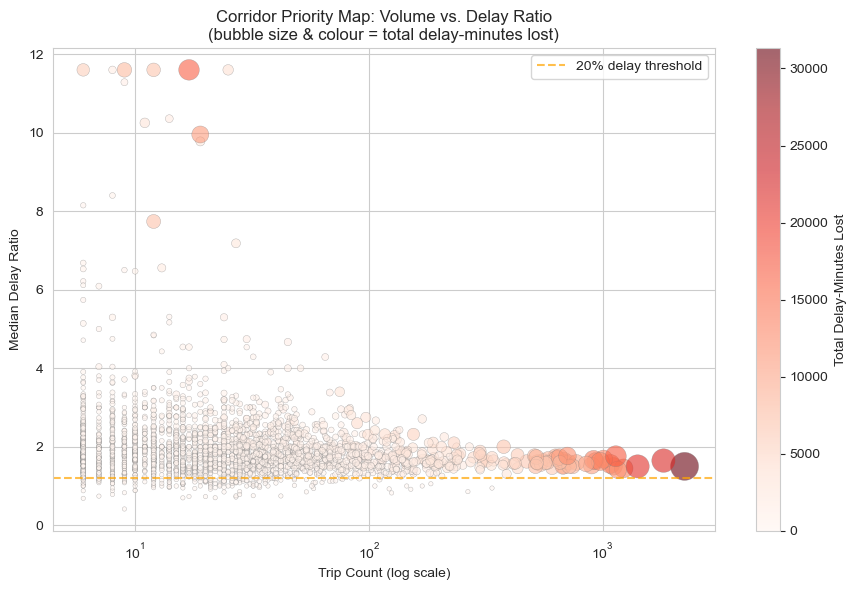


Total delay-minutes lost across all corridors (per observed period): 1,870,606 minutes
Top 10 corridors above account for 9.3% of all delay-minutes lost network-wide.


In [75]:
fig, ax = plt.subplots(figsize=(9, 6))

sample = corridor_ml[corridor_ml['trip_count'] > 5]
sc = ax.scatter(
    sample['trip_count'], sample['median_delay_ratio'],
    s=sample['total_delay_minutes'] / sample['total_delay_minutes'].max() * 400 + 10,
    c=sample['total_delay_minutes'], cmap='Reds', alpha=0.6, edgecolors='grey', linewidths=0.3
)
ax.axhline(1.2, color='orange', linestyle='--', alpha=0.7, label='20% delay threshold')
ax.set_xscale('log')
ax.set_xlabel('Trip Count (log scale)')
ax.set_ylabel('Median Delay Ratio')
ax.set_title('Corridor Priority Map: Volume vs. Delay Ratio\n'
              '(bubble size & colour = total delay-minutes lost)')
ax.legend()
plt.colorbar(sc, ax=ax, label='Total Delay-Minutes Lost')
plt.tight_layout()
plt.show()

print(f"\nTotal delay-minutes lost across all corridors (per observed period): "
      f"{corridor_ml['total_delay_minutes'].sum():,.0f} minutes")
print(f"Top 10 corridors above account for "
      f"{top_delay_minutes['total_delay_minutes'].sum() / corridor_ml['total_delay_minutes'].sum() * 100:.1f}% "
      f"of all delay-minutes lost network-wide.")

**Why this matters:** the bubble chart makes the prioritisation visual,
the large, dark-red bubbles in the upper-right are corridors that are both
high-volume *and* badly delayed, and they're where operational fixes pay off
fastest. A corridor with a delay ratio of 5.0 but only 11 trips (visible
earlier in the "chronic corridors" table) is a much lower priority than a
corridor with a 1.4 ratio but 2,000 trips, yet a ratio-only ranking would put
the former first. This "delay-minutes lost" framing is the bridge between the
graph/ML analysis and the revenue-impact estimate in the memo below.

## Summary Appendix

All key numbers from the analysis, collected in one place for quick reference.

In [78]:
summary = {
    'Total Facilities (Nodes)'                : G.number_of_nodes(),
    'Total Corridors (Edges, collapsed)'      : G.number_of_edges(),
    'Corridor-Mode-Window Combinations'       : len(corridor_stats),
    'Chronically Delayed (>20% over OSRM)'    : f"{len(chronic)} ({len(chronic)/len(corridor_stats)*100:.1f}%)",
    'Baseline MAE (mins)'                     : round(mae_b, 2),
    'Graph-Enhanced MAE (mins)'               : round(mae_g, 2),
    'MAE Improvement (%)'                     : round((mae_b - mae_g) / mae_b * 100, 1),
    'Baseline Within-15% Accuracy (%)'        : round(acc_b, 1),
    'Graph Within-15% Accuracy (%)'           : round(acc_g, 1),
    'Within-15% Lift (pp)'                    : round(acc_g - acc_b, 1),
    'FTL vs Carting Classifier Accuracy (%)'  : round(clf.score(X_te, y_te) * 100, 1),
    'FTL Corridors Flagged for Review'        : len(mismatched_ftl),
    'Carting Corridors Flagged for FTL'       : len(mismatched_carting),
    'Top Bottleneck Hub'                      : f"{hub_metrics.sort_values('Betweenness_Centrality', ascending=False).iloc[0]['Hub']}",
}

print("=" * 60)
print("PROJECT SUMMARY -- DELHIVERY ETA OPTIMISATION")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k:<42} {v}")
print("=" * 60)

PROJECT SUMMARY -- DELHIVERY ETA OPTIMISATION
  Total Facilities (Nodes)                   1240
  Total Corridors (Edges, collapsed)         1635
  Corridor-Mode-Window Combinations          2215
  Chronically Delayed (>20% over OSRM)       2071 (93.5%)
  Baseline MAE (mins)                        17.35
  Graph-Enhanced MAE (mins)                  14.01
  MAE Improvement (%)                        19.2
  Baseline Within-15% Accuracy (%)           24.7
  Graph Within-15% Accuracy (%)              34.3
  Within-15% Lift (pp)                       9.6
  FTL vs Carting Classifier Accuracy (%)     95.8
  FTL Corridors Flagged for Review           631
  Carting Corridors Flagged for FTL          42
  Top Bottleneck Hub                         IND000000ACB


## Limitations & Future Work

- Our graph is built using historical data from a fixed time period, so it represents a snapshot of the network. In practice, the model would need periodic retraining as routes, traffic patterns, and demand change over time.
- For the graph analysis, we use a single edge between each source and destination facility. This helps simplify the network, but it means the centrality and embedding features capture a facility's overall role rather than differences across route types or times of day. A more advanced multi-layer graph could model these factors separately.
- The Node2Vec embeddings are learned once from historical data and do not automatically adapt to new trips or real-time conditions. Future work could explore graph neural networks or temporal graph models that better capture changing network behaviour.
- Our FTL vs. Carting analysis is intended as a decision-support tool. It highlights corridors whose current route type differs from the pattern learned by the model, but operational decisions would still need to consider factors such as fleet availability, costs, and business constraints.